In [1]:
import numpy as np
import meshio
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.interpolate import RegularGridInterpolator

## Load Meshes

In [2]:
fem  = meshio.read("../geometries/ref_01.xdmf")
therm = meshio.read("../results/undistorted_thermal.vtu")

print("FEM  nodes:", fem.points.shape,
      f"  x {fem.points[:,0].min():.1f}–{fem.points[:,0].max():.1f}",
      f"  y {fem.points[:,1].min():.1f}–{fem.points[:,1].max():.1f}",
      f"  z {fem.points[:,2].min():.1f}–{fem.points[:,2].max():.1f}  mm")
print("Therm nodes:", therm.points.shape,
      f"  x {therm.points[:,0].min():.1f}–{therm.points[:,0].max():.1f}",
      f"  y {therm.points[:,1].min():.1f}–{therm.points[:,1].max():.1f}  mm")

FEM  nodes: (9004, 3)   x -80.0–80.0   y 0.0–22.0   z -125.0–125.0  mm
Therm nodes: (168831, 3)   x 0.0–256.0   y 0.0–107.9  mm


## Extract FEM Surface

The FEM mesh is a 3D tetra volume. For thermal mapping we only need the **front face** — the surface nodes visible to the IR camera.

The plate geometry is oriented as:
- x: width (0–160 mm)
- y: thickness (0–22 mm)  ← camera looks along this axis
- z: length (0–250 mm)

We extract the face at `y ≈ 0` (or `y ≈ 22` — whichever faces the camera). Adjust `FACE_Y` if needed.

In [3]:
FACE_Y = 0.0       # y-coordinate of the face visible to the camera (mm)
FACE_TOL = 0.5     # tolerance in mm

mask = np.abs(fem.points[:, 1] - FACE_Y) < FACE_TOL
surface_nodes = fem.points[mask]   # (N, 3)
surface_idx   = np.where(mask)[0]

print(f"Surface nodes at y≈{FACE_Y}: {len(surface_nodes)}")

Surface nodes at y≈0.0: 1356


## Reconstruct the Thermal Grid

The thermal VTU was exported on a regular pixel grid scaled to mm. We reconstruct the 2D image array from the point data so we can use `RegularGridInterpolator`.

In [4]:
tx = np.unique(np.round(therm.points[:, 0], 6))
ty = np.unique(np.round(therm.points[:, 1], 6))
W, H = len(tx), len(ty)

T_img = therm.point_data["temperature"].reshape(H, W)

interp = RegularGridInterpolator(
    (ty, tx), T_img,
    method="linear",
    bounds_error=False,
    fill_value=np.nan,
)

print(f"Thermal grid: {W} x {H} px  →  {tx.max():.1f} x {ty.max():.1f} mm")

Thermal grid: 507 x 333 px  →  256.0 x 107.9 mm


## Coordinate Transform

Map FEM surface coordinates `(x_fem, z_fem)` → thermal image coordinates `(x_therm, y_therm)`.

The transform is:
```
x_therm = scale_x * x_fem + offset_x
y_therm = scale_y * z_fem + offset_y
```

Default: fit the FEM extent into the thermal image extent. Adjust manually if the camera was not centred or angled.

In [5]:
# --- adjust these to align image with mesh ---
scale_x  = tx.max() / fem.points[:, 0].max()   # thermal_width  / fem_width
scale_y  = ty.max() / fem.points[:, 2].max()   # thermal_height / fem_length
offset_x = 0.0   # mm shift in thermal x
offset_y = 0.0   # mm shift in thermal y

x_q = surface_nodes[:, 0] * scale_x + offset_x   # FEM x → thermal x
y_q = surface_nodes[:, 2] * scale_y + offset_y   # FEM z → thermal y

print(f"Scale  x={scale_x:.4f}  y={scale_y:.4f}")
print(f"Query  x {x_q.min():.1f}–{x_q.max():.1f}  y {y_q.min():.1f}–{y_q.max():.1f}  mm")

Scale  x=3.2003  y=0.8635
Query  x -256.0–256.0  y -107.9–107.9  mm


## Resample Temperature onto FEM Surface

In [6]:
T_surface = interp(np.column_stack([y_q, x_q]))   # (y, x) order for RegularGridInterpolator

valid = np.isfinite(T_surface)
print(f"Mapped {valid.sum()} / {len(T_surface)} surface nodes  "
      f"({100*valid.mean():.1f}% coverage)")
print(f"T range: {np.nanmin(T_surface):.2f} – {np.nanmax(T_surface):.2f} °C")

Mapped 380 / 1356 surface nodes  (28.0% coverage)
T range: 25.35 – 41.63 °C


## Visualise

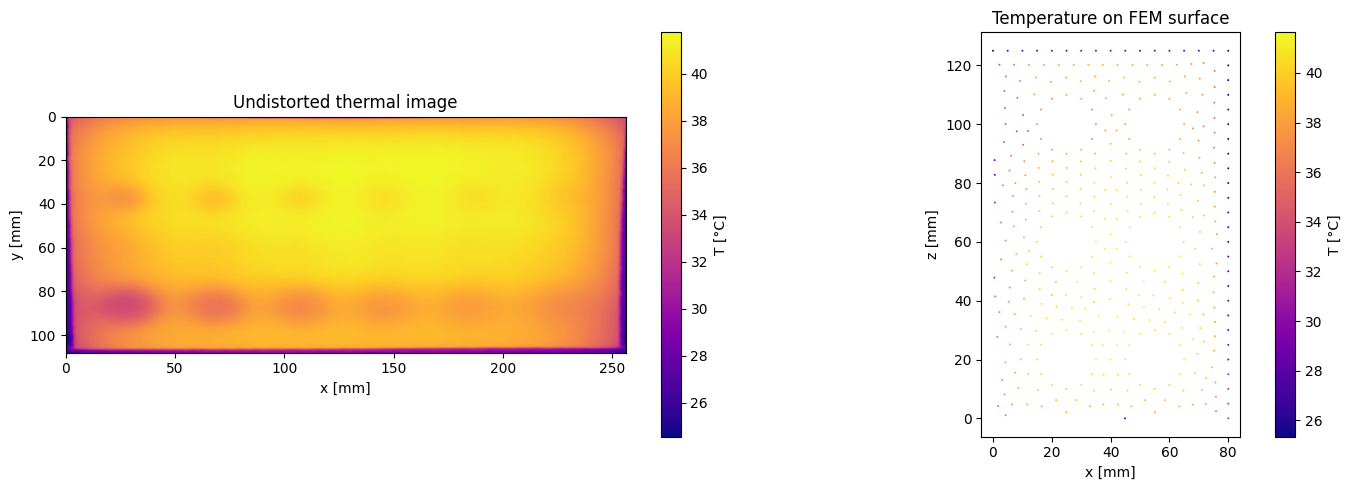

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: original thermal image
im0 = axes[0].imshow(
    T_img, origin="upper",
    extent=[0, tx.max(), ty.max(), 0],
    cmap="plasma",
)
axes[0].set_title("Undistorted thermal image")
axes[0].set_xlabel("x [mm]"); axes[0].set_ylabel("y [mm]")
plt.colorbar(im0, ax=axes[0], label="T [°C]")

# Right: temperature mapped on FEM surface (scatter by node position)
sc = axes[1].scatter(
    surface_nodes[:, 0],
    surface_nodes[:, 2],
    c=T_surface, cmap="plasma",
    s=2, linewidths=0,
)
axes[1].set_title("Temperature on FEM surface")
axes[1].set_xlabel("x [mm]"); axes[1].set_ylabel("z [mm]")
axes[1].set_aspect("equal")
plt.colorbar(sc, ax=axes[1], label="T [°C]")

plt.tight_layout()
plt.show()

## Export Mapped Mesh

In [8]:
# Assign NaN-filled array over all FEM nodes, surface nodes get measured T
T_all = np.full(len(fem.points), np.nan)
T_all[surface_idx] = T_surface

out = meshio.Mesh(
    points=fem.points,
    cells=fem.cells,
    point_data={"temperature_ir": T_all},
)
meshio.write("../results/fem_thermal_mapped.vtu", out)
print("Saved ../results/fem_thermal_mapped.vtu")

Saved ../results/fem_thermal_mapped.vtu
